# Facial Emotion Recognition — FER2013
#### Course: Computer Vision & Robotics Intelligence

This notebook trains **two models** and compares them:
| Model | Type | Expected Accuracy |
|-------|------|------------------|
| **Model 1** | Custom CNN (trained from scratch) | ~62% |
| **Model 2** | EfficientNetB0 (Transfer Learning) | ~68–72% |

**Dataset:** FER2013 — 35,887 grayscale 48×48 face images, 7 emotion classes.

> ⚡ Before running: Runtime → Change runtime type → **T4 GPU**

---
## Step 1 — Install Libraries & Check GPU

In [1]:
!pip install -q kagglehub tensorflow scikit-learn matplotlib seaborn

import os, numpy as np, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import Image, display
from datetime import datetime

print(f'TensorFlow : {tf.__version__}')
print(f'GPU found  : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.19.0
GPU found  : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Step 2 — Download FER2013 Dataset

In [2]:
import kagglehub

# Download FER2013 from Kaggle (msambare/fer2013)
# Dataset has 7 emotion folders: angry, disgust, fear, happy, sad, surprise, neutral
path = kagglehub.dataset_download('msambare/fer2013')
print('Downloaded to:', path)

# Locate the train/ and test/ folders inside the downloaded path
TRAIN_DIR, TEST_DIR = None, None
for root, dirs, _ in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        TRAIN_DIR = os.path.join(root, 'train')
        TEST_DIR  = os.path.join(root, 'test')
        break

assert TRAIN_DIR, 'Could not find train/ folder in dataset!'

# Count images and print class info
classes = sorted(os.listdir(TRAIN_DIR))
n_train = sum(len(f) for _, _, f in os.walk(TRAIN_DIR))
n_test  = sum(len(f) for _, _, f in os.walk(TEST_DIR))

print(f'\nClasses ({len(classes)}): {classes}')
print(f'Train images : {n_train}')
print(f'Test  images : {n_test}')

# Print class counts
print('\nPer-class counts:')
for cls in classes:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f'  {cls:<12} : {n}')

Using Colab cache for faster access to the 'fer2013' dataset.
Downloaded to: /kaggle/input/fer2013

Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train images : 28709
Test  images : 7178

Per-class counts:
  angry        : 3995
  disgust      : 436
  fear         : 4097
  happy        : 7215
  neutral      : 4965
  sad          : 4830
  surprise     : 3171


---
## Step 3 — Configuration

In [3]:
# ── Shared settings ──────────────────────────────────────────────
NUM_CLASSES    = 7
EMOTION_LABELS = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
BATCH_SIZE     = 64

# ── Model 1: Custom CNN ──────────────────────────────────────────
CNN_IMG_SIZE   = 48           # Grayscale 48x48 (original FER2013 resolution)
CNN_EPOCHS     = 60
CNN_LR         = 5e-4

# ── Model 2: EfficientNetB0 Transfer Learning ────────────────────
EFF_IMG_SIZE   = 96           # RGB 96x96 (EfficientNet needs at least 96x96)
EFF_EPOCHS_P1  = 20           # Phase 1: train head only (base frozen)
EFF_EPOCHS_P2  = 35           # Phase 2: fine-tune top layers
EFF_LR_P1      = 1e-3
EFF_LR_P2      = 5e-5
LABEL_SMOOTH   = 0.1

# ── Output directories ───────────────────────────────────────────
MODEL_DIR   = '/content/trained_models'
RESULTS_DIR = '/content/training_results'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Config ready.')

Config ready.


---
## Step 4 — Visualize Dataset

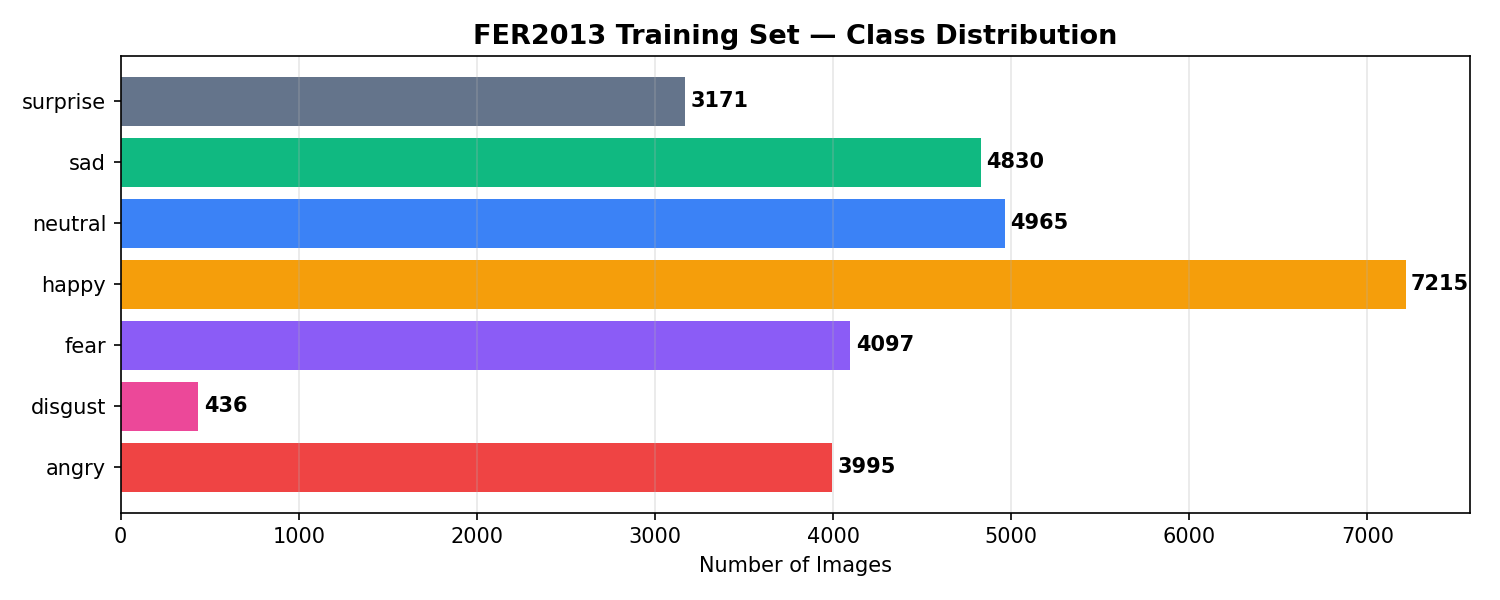

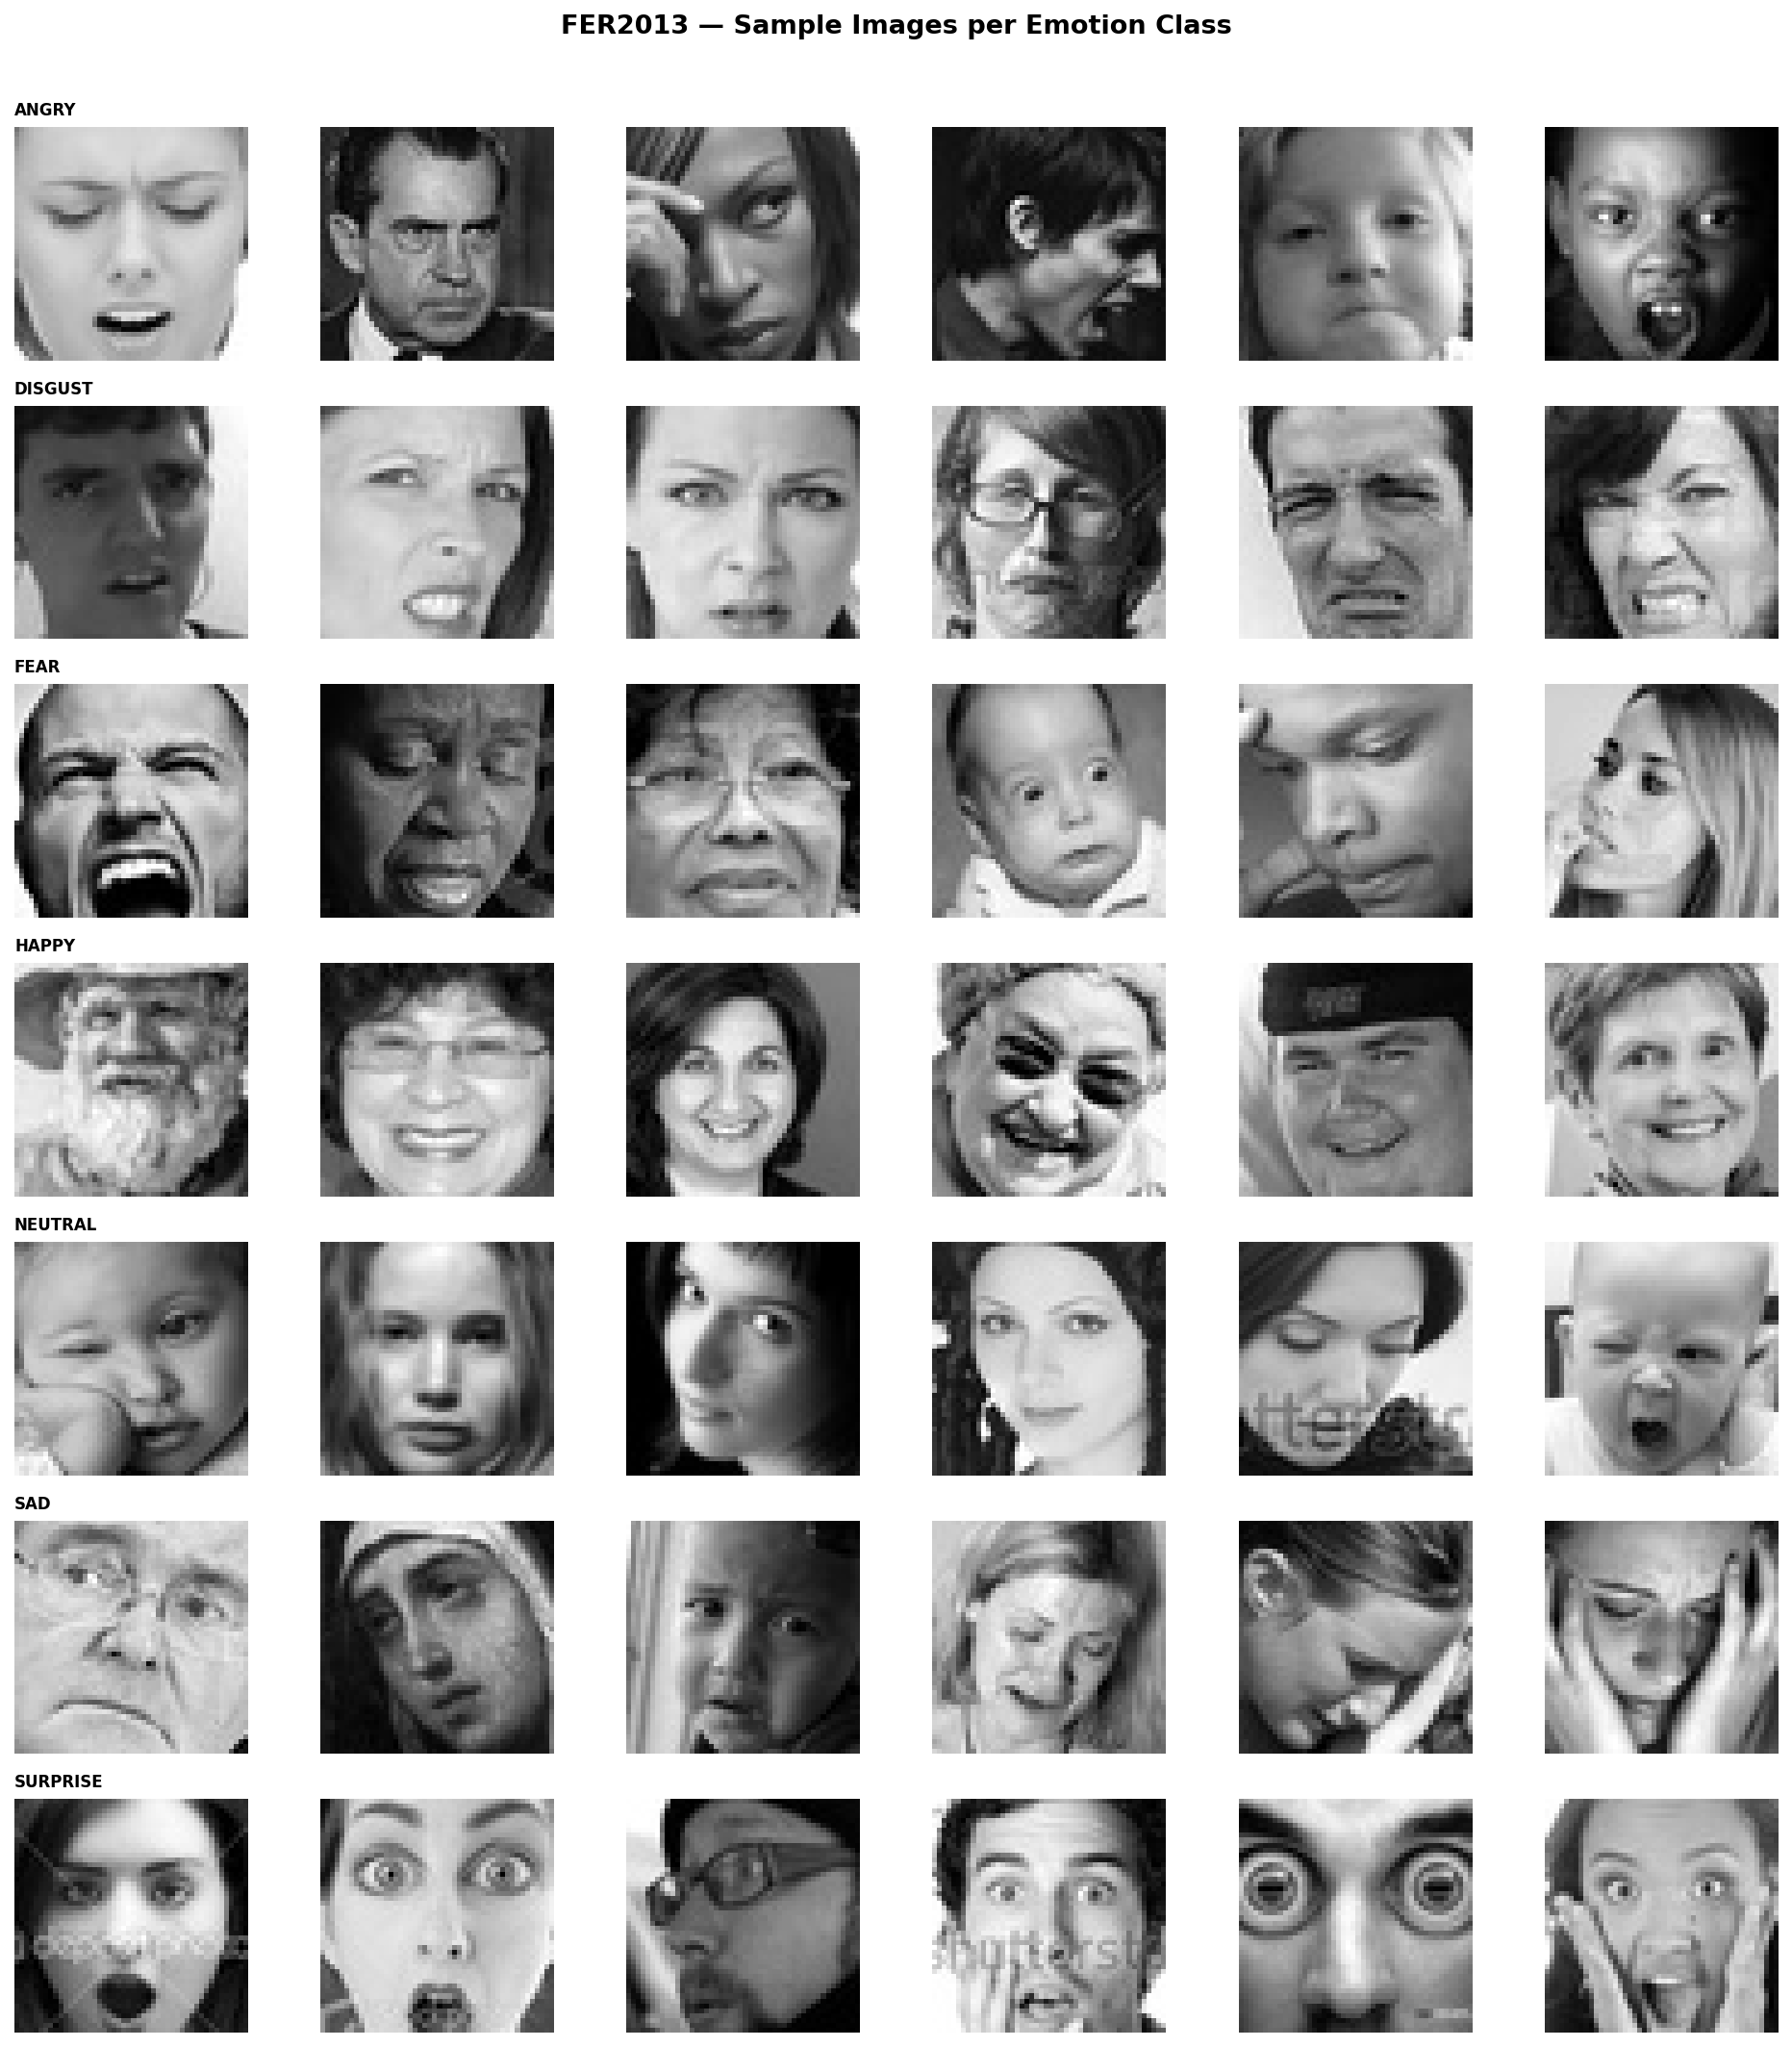

In [4]:
import cv2

#  Class distribution bar chart
class_counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in classes}

colors = ['#ef4444','#ec4899','#8b5cf6','#f59e0b','#3b82f6','#10b981','#64748b']
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(list(class_counts.keys()), list(class_counts.values()), color=colors)
for bar, (cls, cnt) in zip(bars, class_counts.items()):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2, str(cnt), va='center', fontweight='bold')
ax.set_title('FER2013 Training Set — Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Images')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/class_distribution.png', dpi=150)
plt.close()
display(Image(f'{RESULTS_DIR}/class_distribution.png'))

# Sample images per class
fig, axs = plt.subplots(len(classes), 6, figsize=(13, len(classes) * 2))
fig.suptitle('FER2013 — Sample Images per Emotion Class', fontsize=13, fontweight='bold', y=1.01)
for i, cls in enumerate(classes):
    imgs = os.listdir(os.path.join(TRAIN_DIR, cls))[:6]
    for j, name in enumerate(imgs):
        img = cv2.imread(os.path.join(TRAIN_DIR, cls, name), cv2.IMREAD_GRAYSCALE)
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].axis('off')
    axs[i, 0].set_title(cls.upper(), fontsize=8, fontweight='bold', loc='left')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/dataset_samples.png', dpi=150, bbox_inches='tight')
plt.close()
display(Image(f'{RESULTS_DIR}/dataset_samples.png'))

---
## Step 5 — Data Generators
Create generators for both models. Training uses heavy augmentation to prevent overfitting.

In [5]:
def make_generators(img_size, color_mode='rgb'):
    """Create train / validation / test generators for a given image size."""
    train_aug = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.15,
        height_shift_range=0.15,
        horizontal_flip=True,
        zoom_range=0.15,
        shear_range=0.1,
        brightness_range=[0.7, 1.3],
        fill_mode='nearest',
        validation_split=0.1
    )
    test_aug = ImageDataGenerator(rescale=1./255)

    kw = dict(target_size=(img_size, img_size), batch_size=BATCH_SIZE,
              color_mode=color_mode, class_mode='categorical')

    train_gen = train_aug.flow_from_directory(TRAIN_DIR, shuffle=True,  subset='training',   **kw)
    val_gen   = train_aug.flow_from_directory(TRAIN_DIR, shuffle=False, subset='validation', **kw)
    test_gen  = test_aug.flow_from_directory( TEST_DIR,  shuffle=False, **kw)
    return train_gen, val_gen, test_gen

# Generators for Model 1 (48x48 grayscale)
train1, val1, test1 = make_generators(CNN_IMG_SIZE, color_mode='grayscale')

# Generators for Model 2 (96x96 RGB)
train2, val2, test2 = make_generators(EFF_IMG_SIZE, color_mode='rgb')

# Compute class weights (to handle class imbalance — e.g. happy has 3x more images than disgust)
cw_arr = compute_class_weight('balanced', classes=np.unique(train1.classes), y=train1.classes)
CLASS_WEIGHTS = dict(enumerate(cw_arr))
print('Class weights:', {k: round(v, 2) for k, v in CLASS_WEIGHTS.items()})

Found 25841 images belonging to 7 classes.
Found 2868 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Found 25841 images belonging to 7 classes.
Found 2868 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class weights: {0: np.float64(1.03), 1: np.float64(9.39), 2: np.float64(1.0), 3: np.float64(0.57), 4: np.float64(0.83), 5: np.float64(0.85), 6: np.float64(1.29)}


---
## Step 6 — Model 1: Custom CNN (From Scratch)
4 convolutional blocks → GlobalAveragePooling → Dense classifier

In [6]:
def build_custom_cnn():
    """
    Custom CNN Architecture
    Input  : 48x48x1 (grayscale)
    Blocks : 4x [Conv→BN→Conv→BN→MaxPool→Dropout]
    Head   : GlobalAvgPool → Dense(512) → Dense(256) → Dense(7, softmax)
    """
    model = keras.Sequential(name='Custom_CNN', layers=[
        # Block 1
        layers.Conv2D(64, 3, padding='same', activation='relu', input_shape=(48, 48, 1)),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2), layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2), layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(256, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(256, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2), layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(512, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2), layers.Dropout(0.25),

        # Classifier head
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'), layers.BatchNormalization(), layers.Dropout(0.5),
        layers.Dense(256, activation='relu'), layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(CNN_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    model.summary()
    return model

cnn_model = build_custom_cnn()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,728,903 (10.41 MB)

 Trainable params: 2,724,551 (10.39 MB)

 Non-trainable params: 4,352 (17.00 KB)

---
## Step 7 — Train Model 1: Custom CNN

In [7]:
cnn_ckpt = f'{MODEL_DIR}/cnn_best.keras'

cnn_callbacks = [
    callbacks.ModelCheckpoint(cnn_ckpt, monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
]

print('Training Custom CNN...')
cnn_history = cnn_model.fit(
    train1, epochs=CNN_EPOCHS,
    validation_data=val1,
    callbacks=cnn_callbacks,
    class_weight=CLASS_WEIGHTS,
    verbose=1
)
print(f"Best val accuracy: {max(cnn_history.history['val_accuracy'])*100:.2f}%")

Training Custom CNN...
Epoch 1/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.1469 - loss: 2.6618
Epoch 1: val_accuracy improved from None to 0.01499, saving model to /content/trained_models/cnn_best.keras

Epoch 1: finished saving model to /content/trained_models/cnn_best.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 165s 359ms/step - accuracy: 0.1478 - loss: 2.5001 - val_accuracy: 0.0150 - val_loss: 2.8976 - learning_rate: 5.0000e-04
Epoch 2/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.1491 - loss: 2.2442
Epoch 2: val_accuracy improved from 0.01499 to 0.19177, saving model to /content/trained_models/cnn_best.keras

Epoch 2: finished saving model to /content/trained_models/cnn_best.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 43s 106ms/step - accuracy: 0.1464 - loss: 2.2041 - val_accuracy: 0.1918 - val_loss: 1.9412 - learning_rate: 5.0000e-04
Epoch 3/60
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.1527 - loss: 2.1064
Epoch 3: val_accuracy did not improve from 0.19177


---
## Step 8 — Model 2: EfficientNetB0 (Transfer Learning)
**Phase 1:** Freeze base → train only the top classifier head  
**Phase 2:** Unfreeze top 50 layers → fine-tune at a very low learning rate

In [8]:
def build_efficientnet():
    """
    EfficientNetB0 Transfer Learning
    Input     : 96x96x3 (RGB)
    Base      : EfficientNetB0 pretrained on ImageNet (frozen initially)
    Head      : GAP → BN → Dense(512) → Dropout → Dense(256) → Dropout → Dense(7, softmax)
    """
    inputs = keras.Input(shape=(EFF_IMG_SIZE, EFF_IMG_SIZE, 3))

    # EfficientNet expects [0, 255], but our generator outputs [0, 1], so rescale back
    x = layers.Rescaling(255.0)(inputs)

    base = keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_tensor=x)
    base.trainable = False  # Freeze all base layers initially

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs=base.input, outputs=outputs, name='EfficientNetB0_TL')
    return model, base

eff_model, base_model = build_efficientnet()
print(f'Total params     : {eff_model.count_params():,}')
print(f'Trainable params : {sum(np.prod(w.shape) for w in eff_model.trainable_weights):,} (head only)')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total params     : 4,843,690
Trainable params : 791,559 (head only)


### Phase 1 — Train Head (Base Frozen)

In [9]:
eff_model.compile(
    optimizer=keras.optimizers.Adam(EFF_LR_P1),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

eff_ckpt_p1 = f'{MODEL_DIR}/eff_phase1_best.keras'
cb_p1 = [
    callbacks.ModelCheckpoint(eff_ckpt_p1, monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print('Phase 1 — Training head only (base frozen)...')
eff_history_p1 = eff_model.fit(
    train2, epochs=EFF_EPOCHS_P1,
    validation_data=val2,
    callbacks=cb_p1,
    class_weight=CLASS_WEIGHTS,
    verbose=1
)
print(f"Phase 1 best val accuracy: {max(eff_history_p1.history['val_accuracy'])*100:.2f}%")

Phase 1 — Training head only (base frozen)...
Epoch 1/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.2326 - loss: 2.1993
Epoch 1: val_accuracy improved from None to 0.31137, saving model to /content/trained_models/eff_phase1_best.keras

Epoch 1: finished saving model to /content/trained_models/eff_phase1_best.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 174s 356ms/step - accuracy: 0.2676 - loss: 2.0312 - val_accuracy: 0.3114 - val_loss: 1.8954 - learning_rate: 0.0010
Epoch 2/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.3003 - loss: 1.9195
Epoch 2: val_accuracy improved from 0.31137 to 0.37204, saving model to /content/trained_models/eff_phase1_best.keras

Epoch 2: finished saving model to /content/trained_models/eff_phase1_best.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 109s 269ms/step - accuracy: 0.3104 - loss: 1.8952 - val_accuracy: 0.3720 - val_loss: 1.8172 - learning_rate: 0.0010
Epoch 3/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.3400 - loss: 1.8630
Epoch

### Phase 2 — Fine-Tune Top 50 Layers

In [10]:
# Unfreeze the top 50 layers of EfficientNetB0 base
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_now = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfrozen base layers: {trainable_now} / {len(base_model.layers)}')

# Recompile with very low LR to avoid destroying pretrained weights
eff_model.compile(
    optimizer=keras.optimizers.Adam(EFF_LR_P2),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

eff_ckpt_p2 = f'{MODEL_DIR}/eff_phase2_best.keras'
cb_p2 = [
    callbacks.ModelCheckpoint(eff_ckpt_p2, monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-8, verbose=1)
]

print('Phase 2 — Fine-tuning top 50 layers...')
eff_history_p2 = eff_model.fit(
    train2, epochs=EFF_EPOCHS_P2,
    validation_data=val2,
    callbacks=cb_p2,
    class_weight=CLASS_WEIGHTS,
    verbose=1
)
print(f"Phase 2 best val accuracy: {max(eff_history_p2.history['val_accuracy'])*100:.2f}%")

Unfrozen base layers: 50 / 239
Phase 2 — Fine-tuning top 50 layers...
Epoch 1/35
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.3358 - loss: 1.8765
Epoch 1: val_accuracy improved from None to 0.39296, saving model to /content/trained_models/eff_phase2_best.keras

Epoch 1: finished saving model to /content/trained_models/eff_phase2_best.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 175s 350ms/step - accuracy: 0.3531 - loss: 1.8413 - val_accuracy: 0.3930 - val_loss: 1.7703 - learning_rate: 5.0000e-05
Epoch 2/35
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.3910 - loss: 1.7521
Epoch 2: val_accuracy improved from 0.39296 to 0.40202, saving model to /content/trained_models/eff_phase2_best.keras

Epoch 2: finished saving model to /content/trained_models/eff_phase2_best.keras
404/404 ━━━━━━━━━━━━━━━━━━━━ 110s 272ms/step - accuracy: 0.3948 - loss: 1.7537 - val_accuracy: 0.4020 - val_loss: 1.7519 - learning_rate: 5.0000e-05
Epoch 3/35
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accur

---
## Step 9 — Plot Training History (Both Models)

=== Model 1: Custom CNN ===


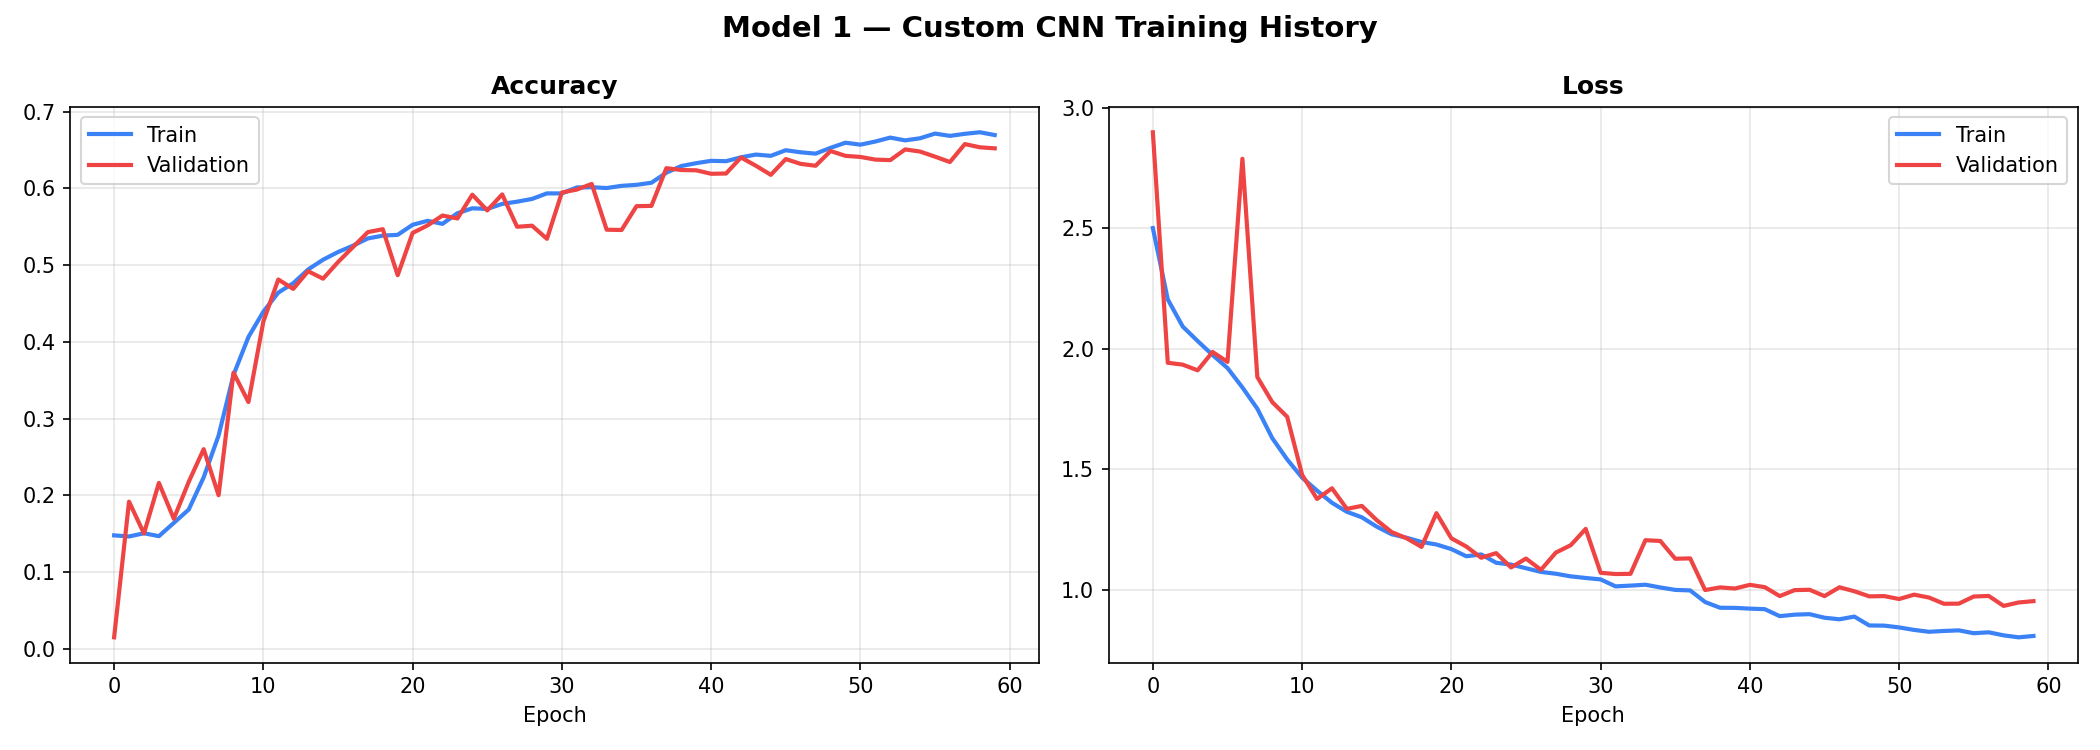

=== Model 2: EfficientNetB0 (Phase 1 + Phase 2) ===


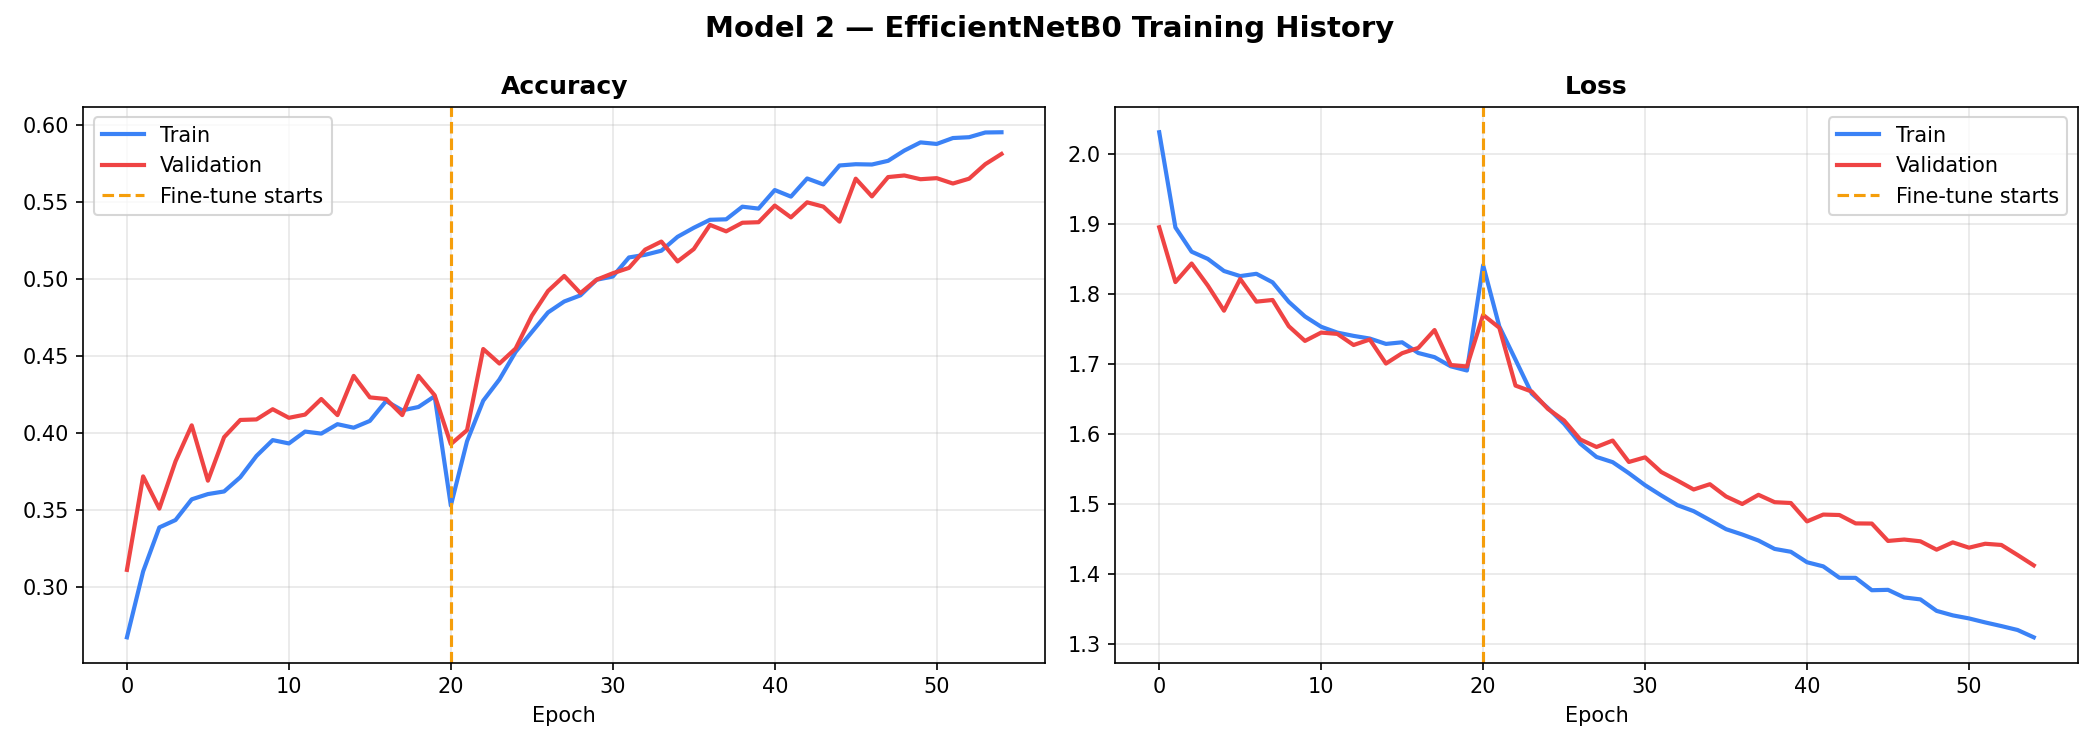

In [11]:
def plot_history(history, title, save_path, phase_split=None):
    """Plot accuracy and loss curves."""
    if isinstance(history, dict):
        h = history
    else:
        h = history.history

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for ax, train_key, val_key, label in zip(
        axes,
        ['accuracy', 'loss'],
        ['val_accuracy', 'val_loss'],
        ['Accuracy', 'Loss']
    ):
        ax.plot(h[train_key], label='Train', color='#3b82f6', linewidth=2)
        ax.plot(h[val_key],   label='Validation', color='#ef4444', linewidth=2)
        if phase_split:
            ax.axvline(phase_split, color='#f59e0b', linestyle='--', label=f'Fine-tune starts')
        ax.set_title(label, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    display(Image(save_path))

# Model 1 history
print('=== Model 1: Custom CNN ===')
plot_history(cnn_history, 'Model 1 — Custom CNN Training History',
             f'{RESULTS_DIR}/history_cnn.png')

# Model 2 history (merge Phase 1 + Phase 2)
print('=== Model 2: EfficientNetB0 (Phase 1 + Phase 2) ===')
merged = {k: eff_history_p1.history[k] + eff_history_p2.history[k]
          for k in ['accuracy','val_accuracy','loss','val_loss']}
plot_history(merged, 'Model 2 — EfficientNetB0 Training History',
             f'{RESULTS_DIR}/history_efficientnet.png',
             phase_split=len(eff_history_p1.history['accuracy']))

---
## Step 10 — Evaluate Both Models
Test accuracy, classification report (precision/recall/F1), and confusion matrix for each model.


  Evaluating: Custom CNN
  Test Accuracy : 66.37%
  Test Loss     : 0.9174

  Classification Report:
              precision    recall  f1-score   support

       Angry     0.5822    0.5992    0.5905       958
     Disgust     0.6090    0.7297    0.6639       111
        Fear     0.5560    0.3682    0.4430      1024
       Happy     0.8941    0.8523    0.8727      1774
     Neutral     0.5503    0.7405    0.6314      1233
         Sad     0.5676    0.5052    0.5346      1247
    Surprise     0.7351    0.8147    0.7728       831

    accuracy                         0.6637      7178
   macro avg     0.6420    0.6585    0.6441      7178
weighted avg     0.6657    0.6637    0.6588      7178



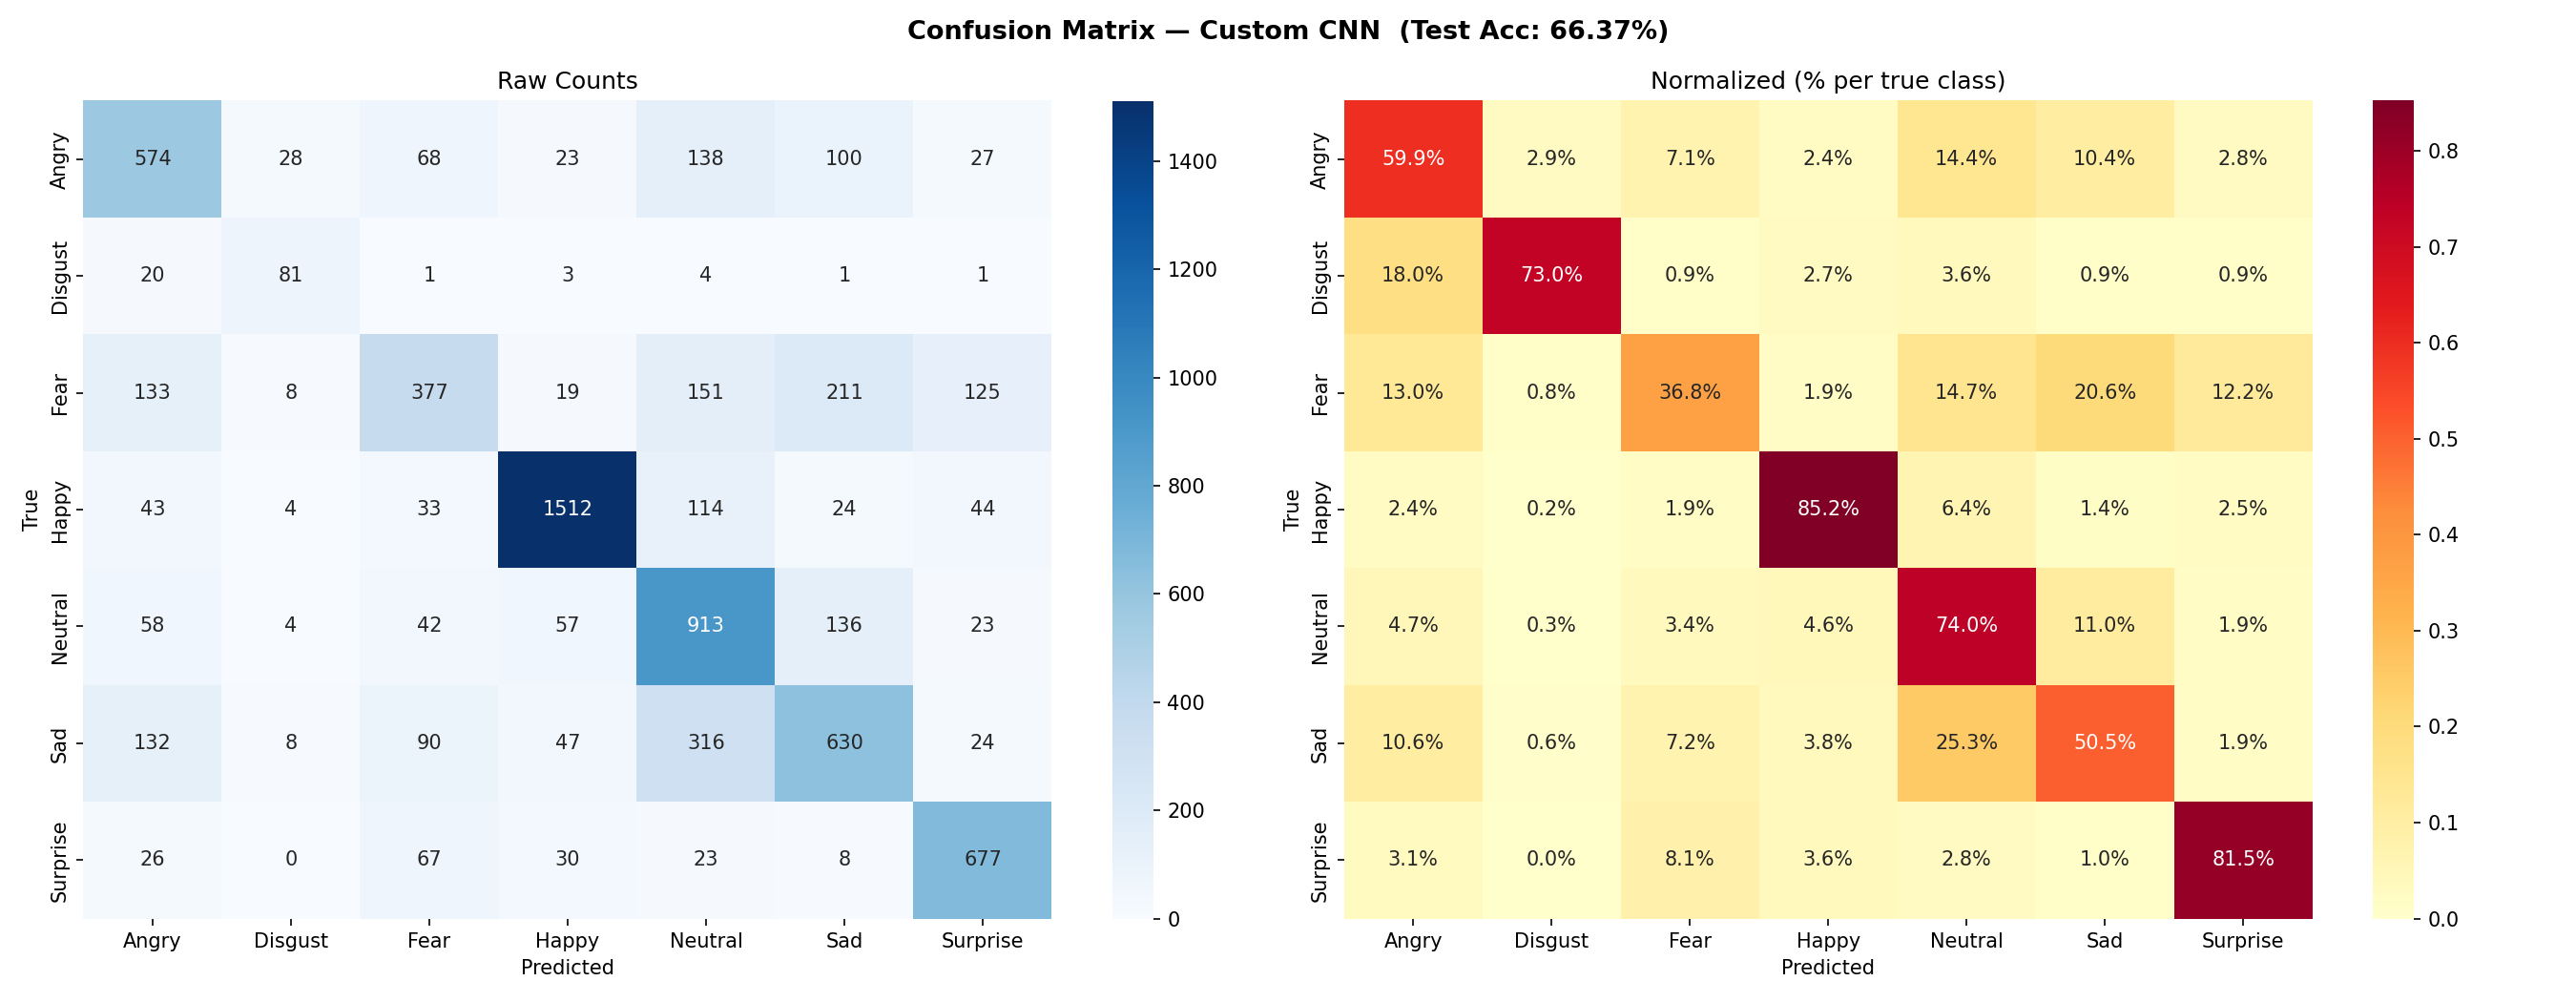

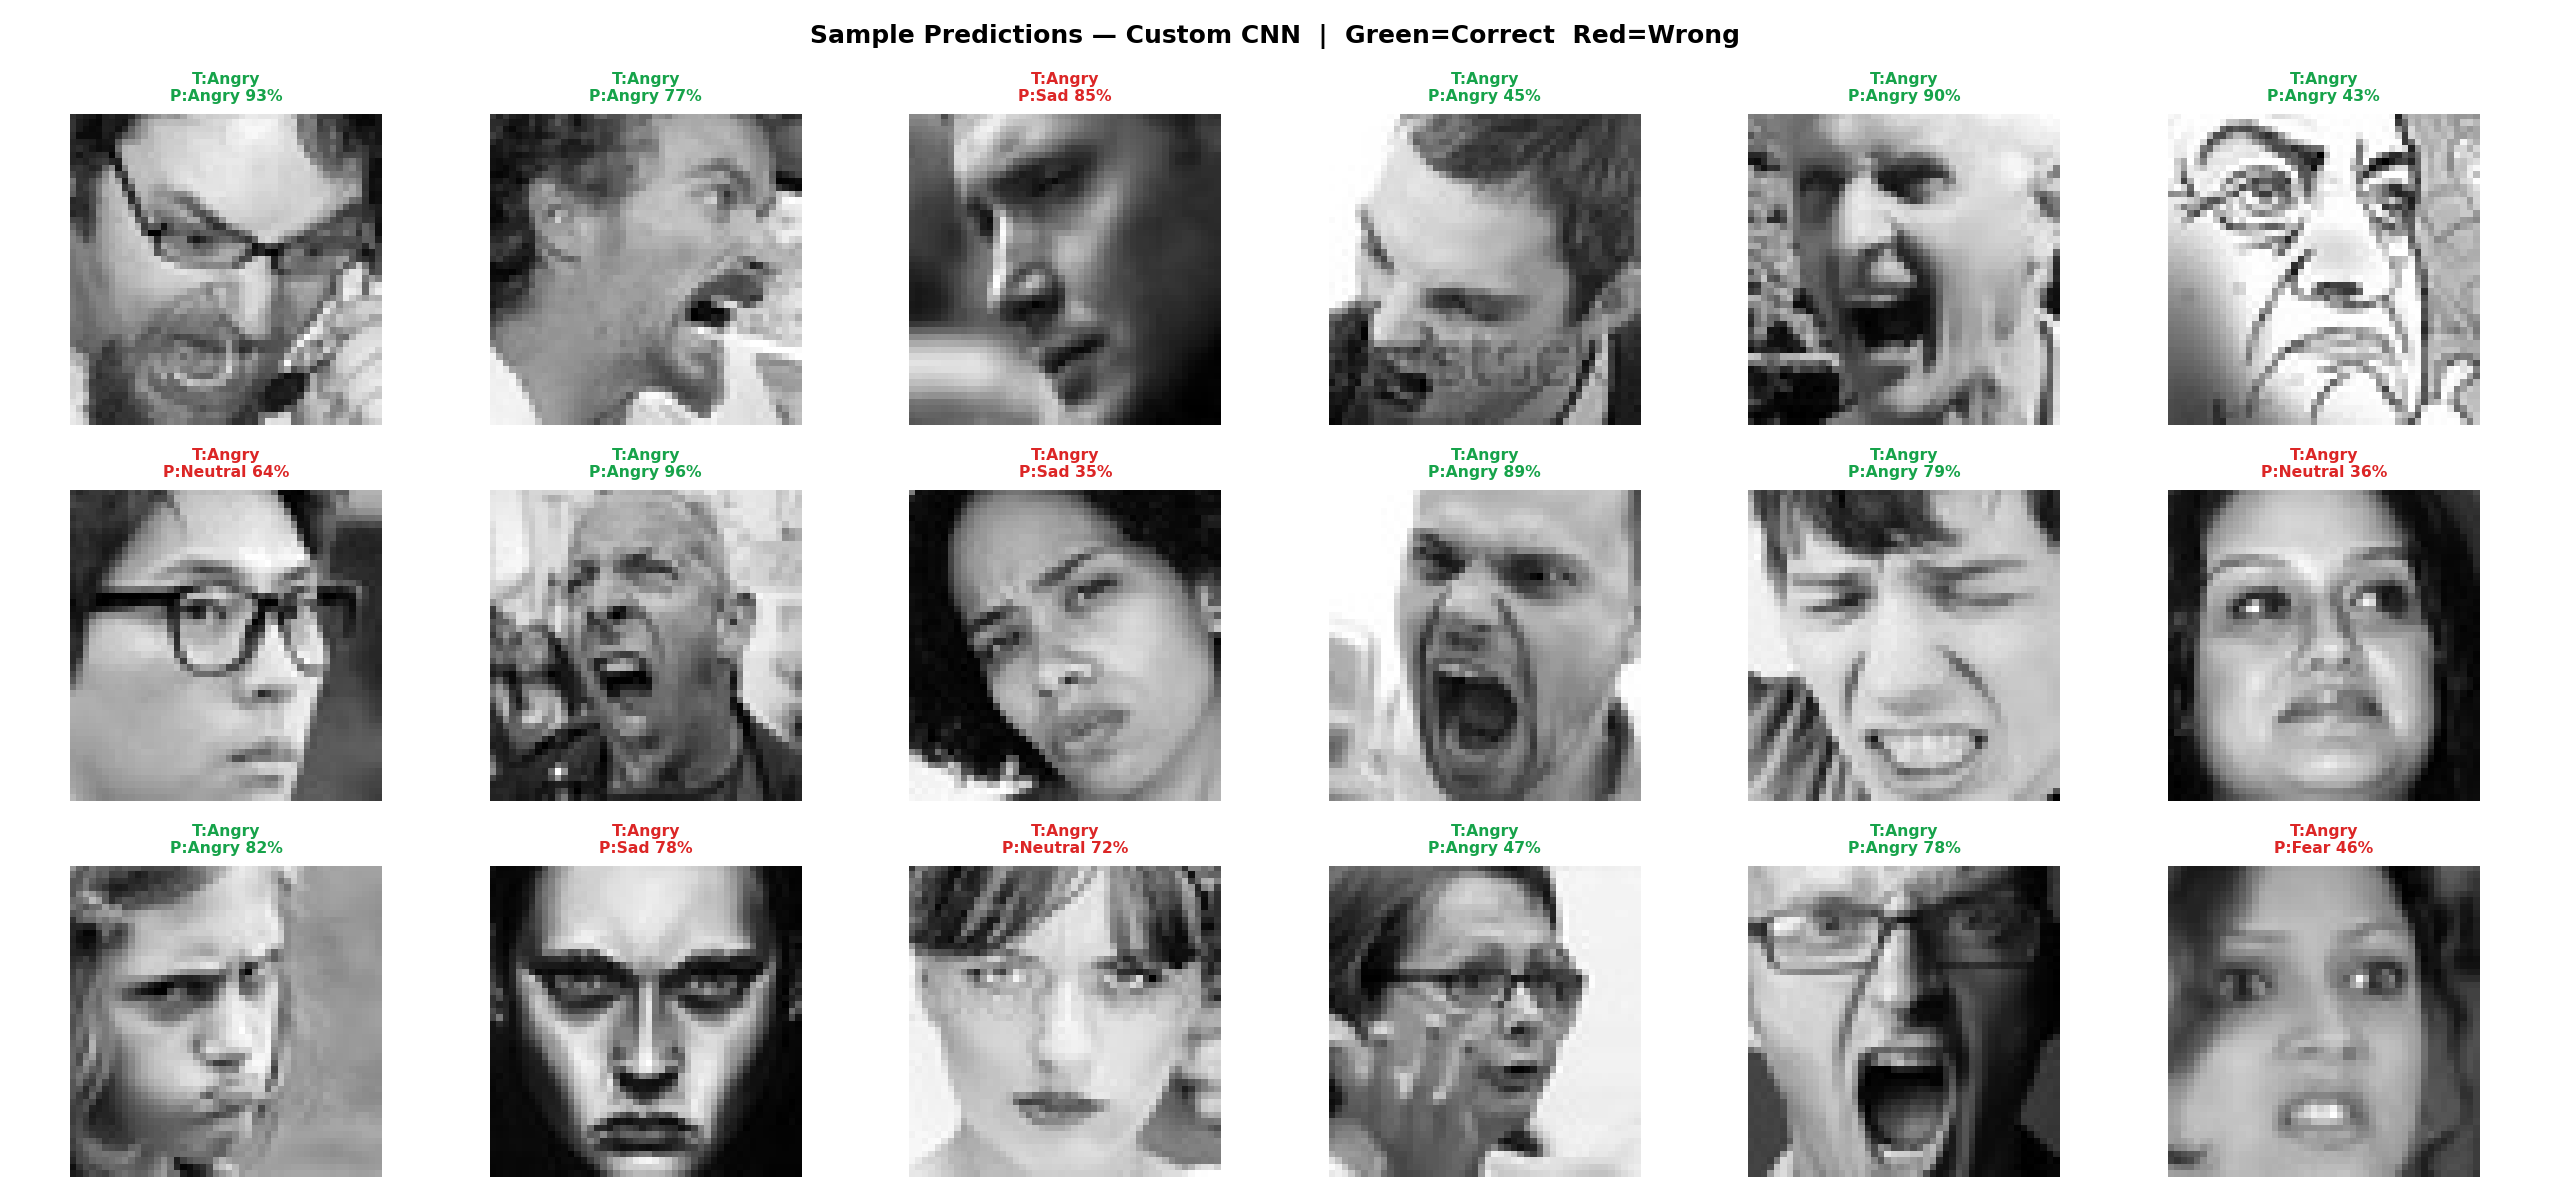


  Evaluating: EfficientNetB0 Transfer Learning
  Test Accuracy : 55.07%
  Test Loss     : 1.4616

  Classification Report:
              precision    recall  f1-score   support

       Angry     0.6187    0.2693    0.3753       958
     Disgust     0.3846    0.5856    0.4643       111
        Fear     0.5489    0.1973    0.2902      1024
       Happy     0.7543    0.7616    0.7579      1774
     Neutral     0.4684    0.5653    0.5123      1233
         Sad     0.3836    0.6319    0.4774      1247
    Surprise     0.6644    0.7124    0.6876       831

    accuracy                         0.5507      7178
   macro avg     0.5461    0.5319    0.5093      7178
weighted avg     0.5773    0.5507    0.5365      7178



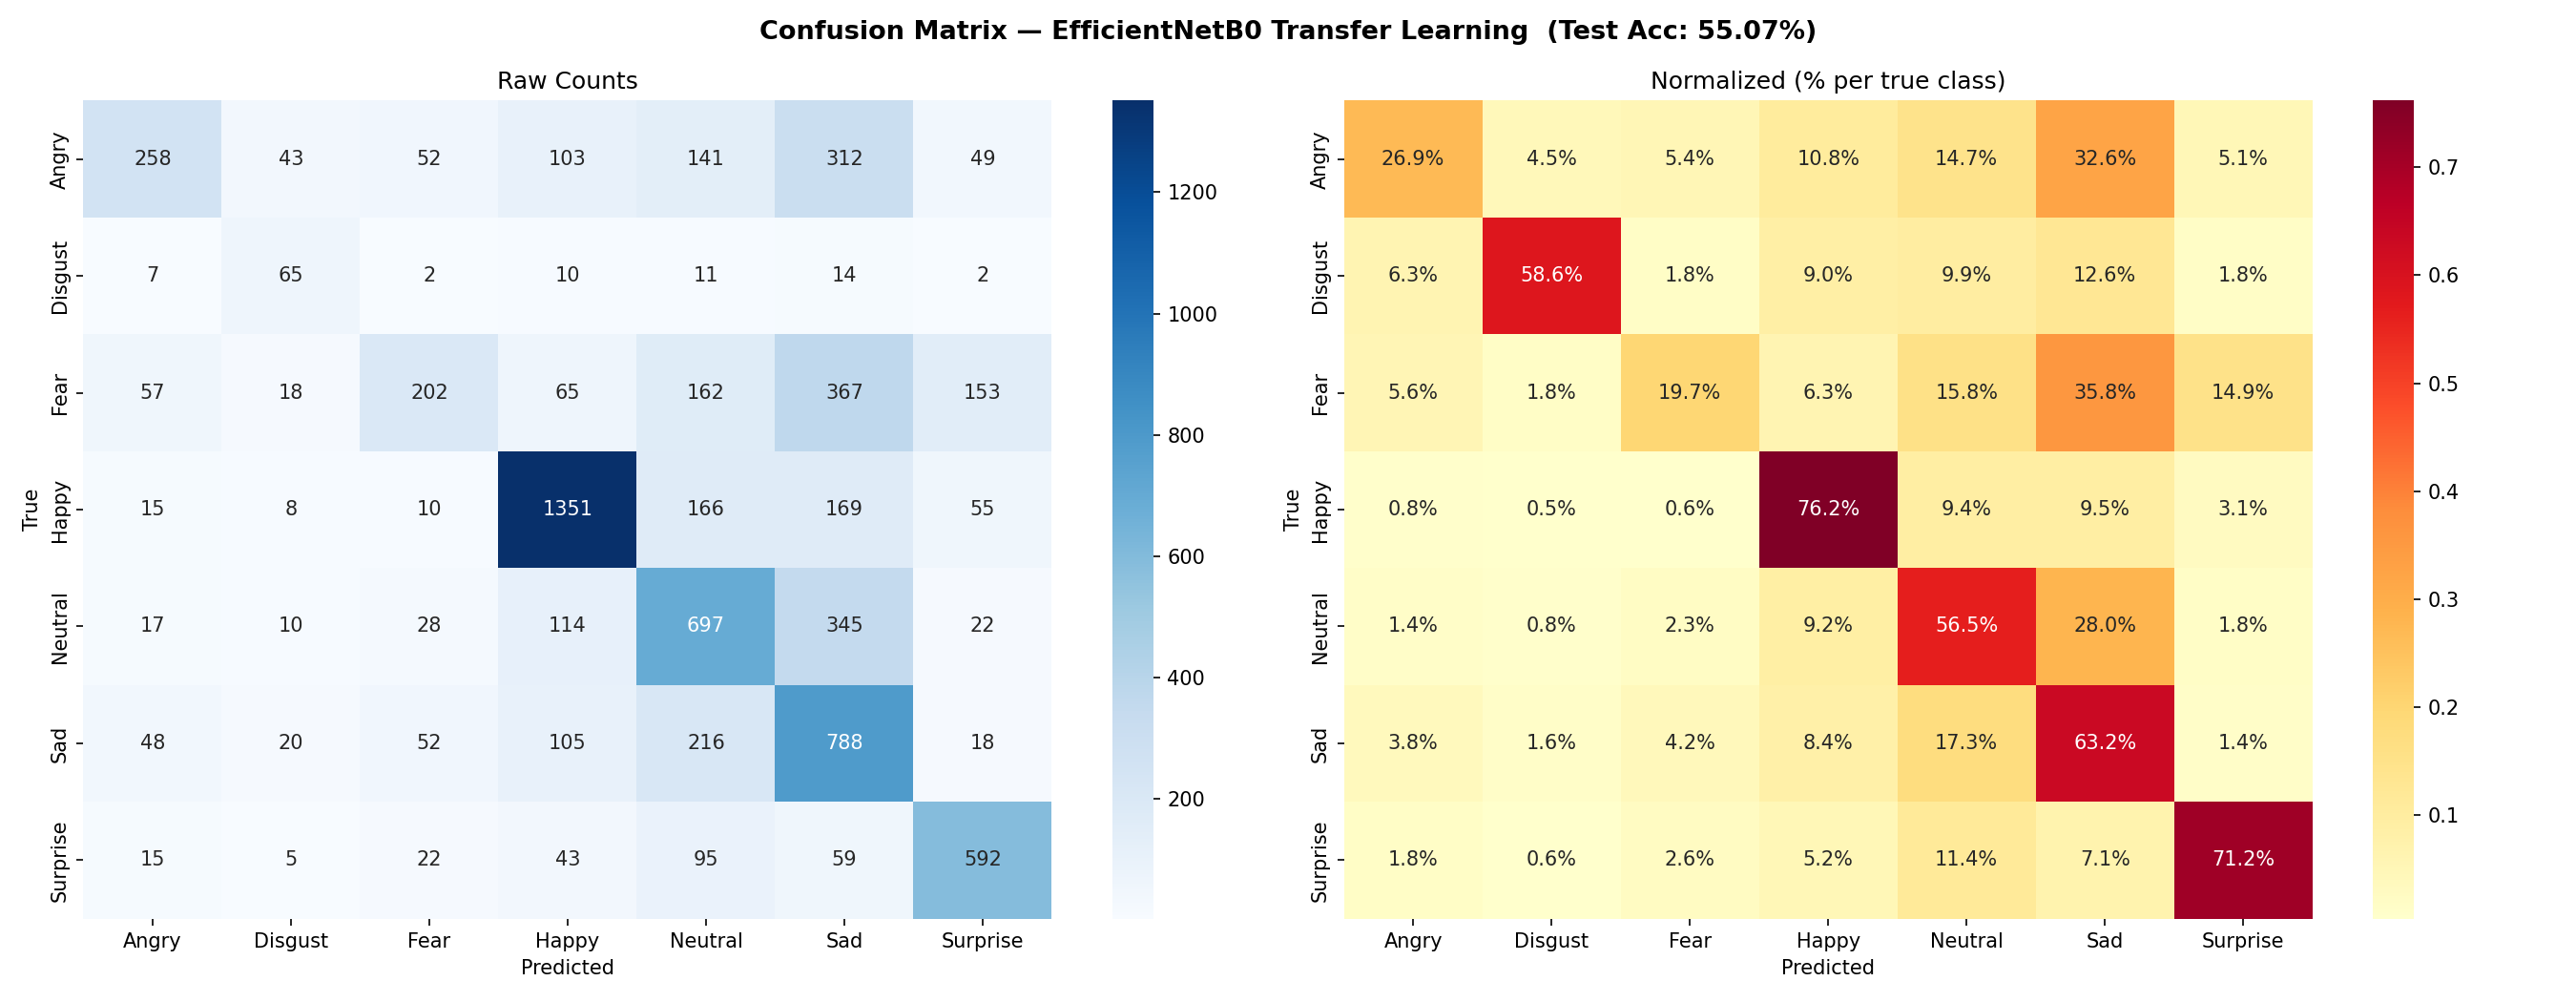

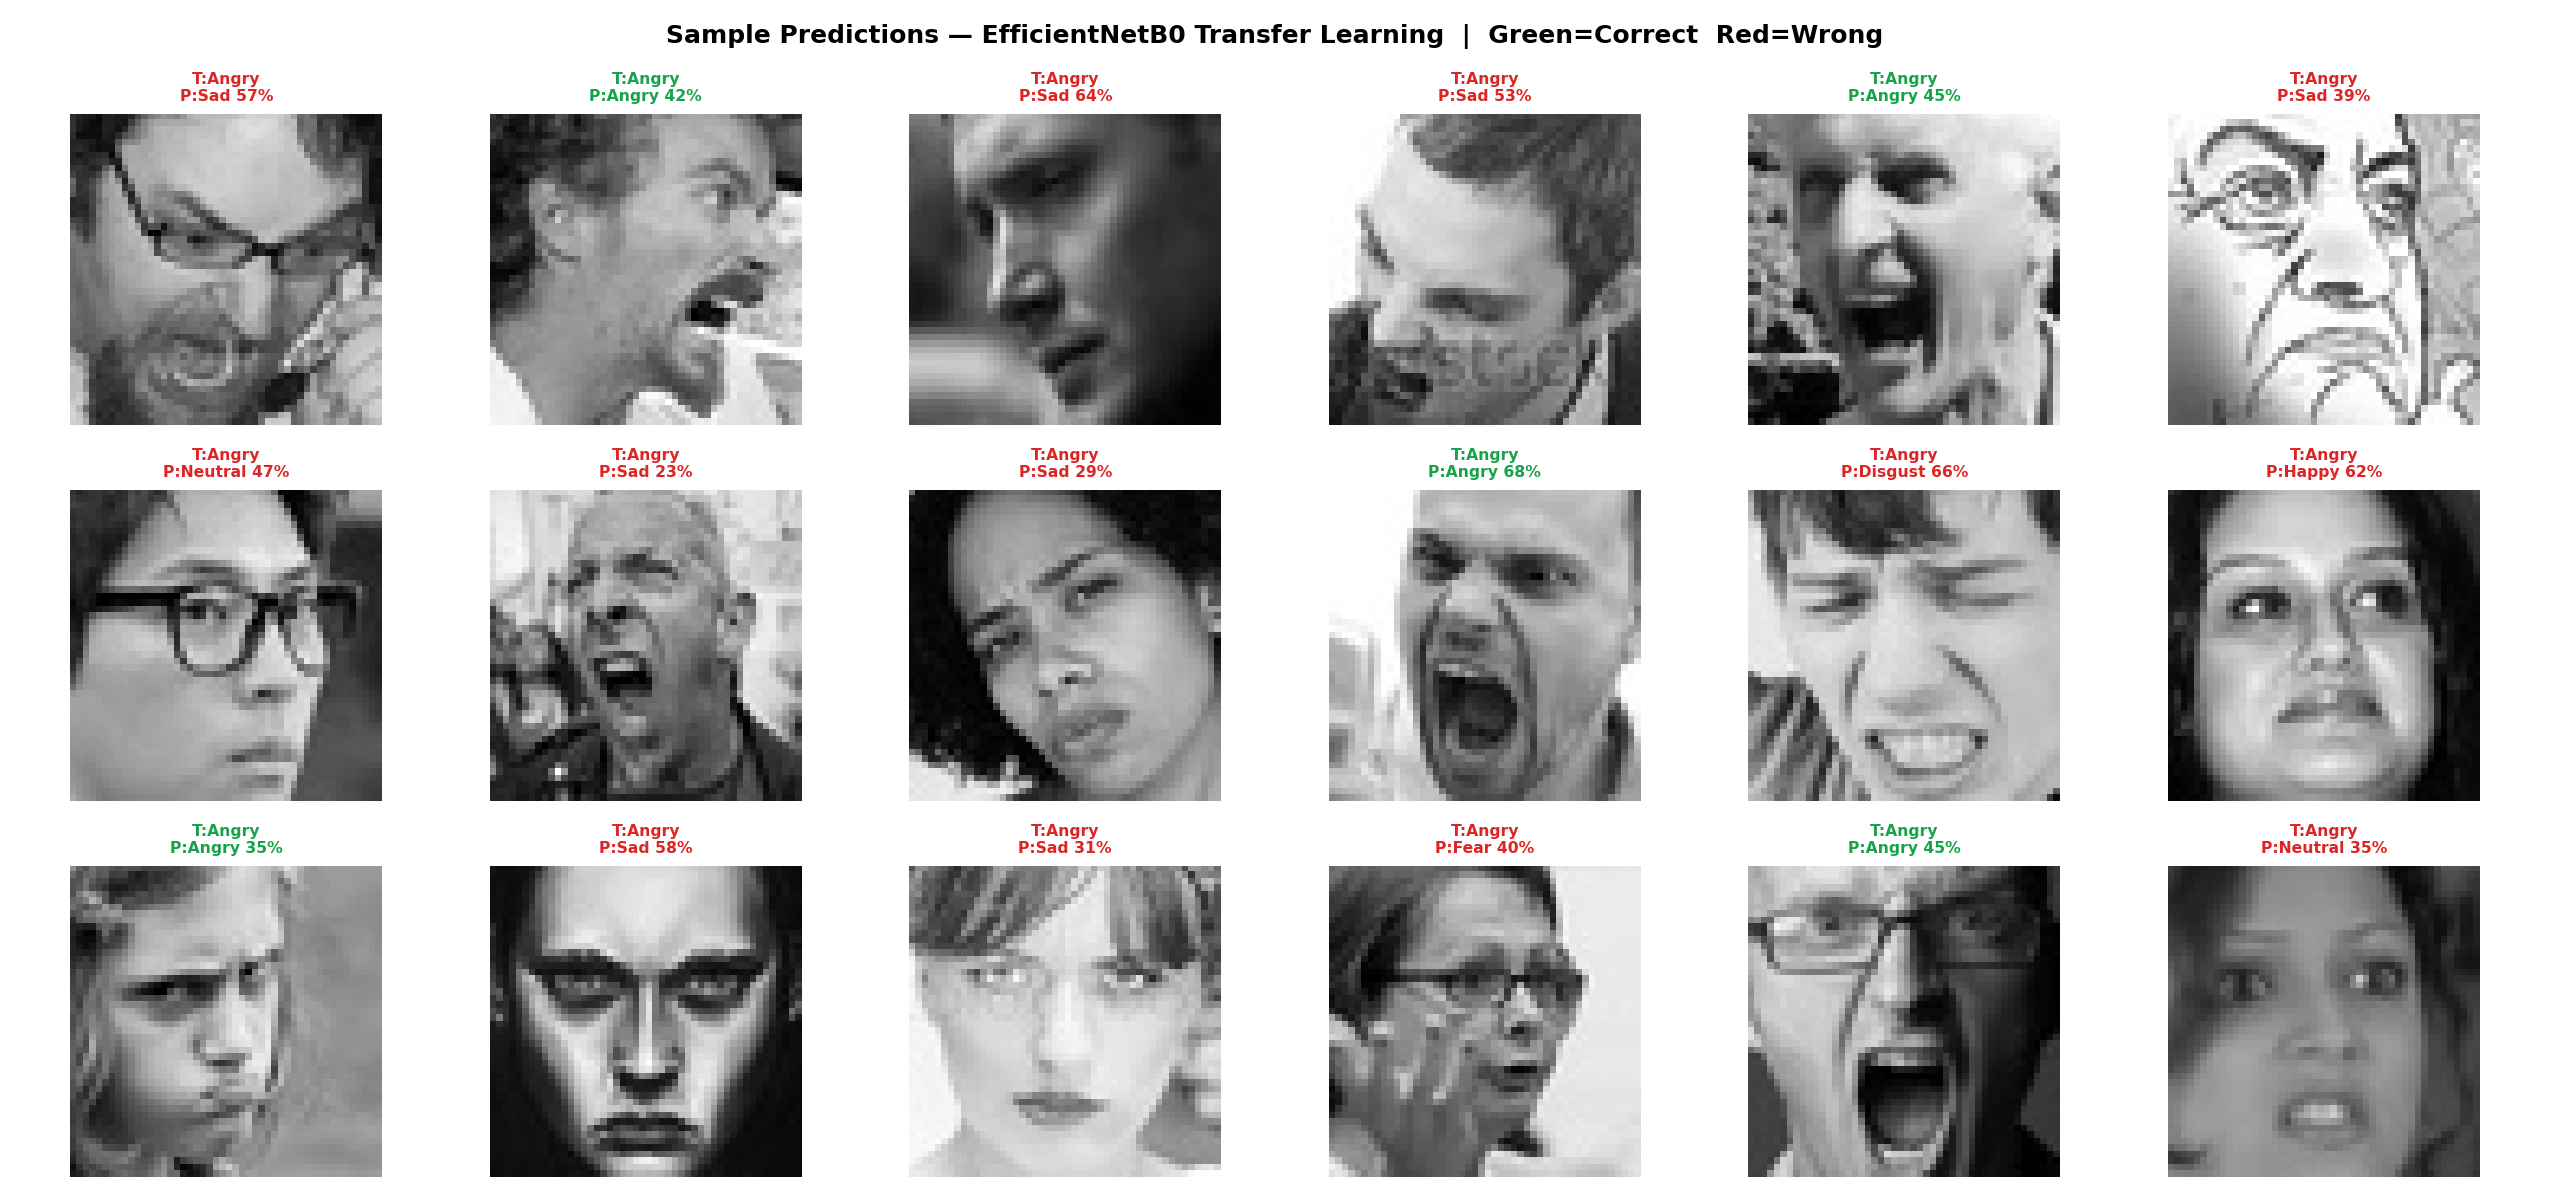

In [12]:
def evaluate_model(model, test_gen, model_name):
    """Full evaluation: accuracy, classification report, confusion matrix (shown inline)."""
    print(f'\n{"="*60}')
    print(f'  Evaluating: {model_name}')
    print(f'{"="*60}')

    # ── Test accuracy & loss ─────────────────────────────────────
    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=0)
    print(f'  Test Accuracy : {acc*100:.2f}%')
    print(f'  Test Loss     : {loss:.4f}')

    # ── Predictions ──────────────────────────────────────────────
    test_gen.reset()
    y_prob  = model.predict(test_gen, verbose=0)
    y_pred  = np.argmax(y_prob, axis=1)
    y_true  = test_gen.classes
    names   = [k for k, _ in sorted(test_gen.class_indices.items(), key=lambda x: x[1])]
    names_c = [n.capitalize() for n in names]

    # ── Classification Report ─────────────────────────────────────
    print(f'\n  Classification Report:')
    report = classification_report(y_true, y_pred, target_names=names_c, digits=4)
    print(report)

    # ── Save report to file ───────────────────────────────────────
    slug = model_name.lower().replace(' ', '_')
    with open(f'{RESULTS_DIR}/report_{slug}.txt', 'w') as f:
        f.write(f'Model: {model_name}\nDate: {datetime.now().strftime("%Y-%m-%d %H:%M")}\n')
        f.write(f'Test Accuracy: {acc*100:.2f}%  |  Test Loss: {loss:.4f}\n\n')
        f.write(report)

    # ── Confusion Matrix (shown inline) ───────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Confusion Matrix — {model_name}  (Test Acc: {acc*100:.2f}%)', fontsize=13, fontweight='bold')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names_c, yticklabels=names_c, ax=axes[0])
    axes[0].set_title('Raw Counts')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')

    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='YlOrRd',
                xticklabels=names_c, yticklabels=names_c, ax=axes[1])
    axes[1].set_title('Normalized (% per true class)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')

    plt.tight_layout()
    cm_path = f'{RESULTS_DIR}/confusion_{slug}.png'
    plt.savefig(cm_path, dpi=150)
    plt.close()
    display(Image(cm_path))

    # ── Sample predictions grid ───────────────────────────────────
    test_gen.reset()
    x_batch, y_batch = next(test_gen)
    n = min(18, len(x_batch))
    preds = model.predict(x_batch[:n], verbose=0)

    fig, axes = plt.subplots(3, 6, figsize=(17, 8))
    fig.suptitle(f'Sample Predictions — {model_name}  |  Green=Correct  Red=Wrong',
                 fontsize=12, fontweight='bold')
    for i in range(n):
        r, c = i // 6, i % 6
        img = x_batch[i]
        axes[r, c].imshow(img.squeeze(), cmap='gray' if img.shape[-1] == 1 else None)
        ti, pi = int(np.argmax(y_batch[i])), int(np.argmax(preds[i]))
        conf   = preds[i][pi] * 100
        color  = '#16a34a' if ti == pi else '#dc2626'
        axes[r, c].set_title(f'T:{names_c[ti]}\nP:{names_c[pi]} {conf:.0f}%',
                              fontsize=7.5, color=color, fontweight='bold')
        axes[r, c].axis('off')
    plt.tight_layout()
    pred_path = f'{RESULTS_DIR}/predictions_{slug}.png'
    plt.savefig(pred_path, dpi=150)
    plt.close()
    display(Image(pred_path))

    return acc, loss

# Evaluate Model 1
cnn_acc, cnn_loss = evaluate_model(cnn_model, test1, 'Custom CNN')

# Evaluate Model 2
eff_acc, eff_loss = evaluate_model(eff_model, test2, 'EfficientNetB0 Transfer Learning')

---
## Step 11 — Compare Both Models


  FINAL COMPARISON
  Model 1 — Custom CNN           : 66.37%  (loss: 0.9174)
  Model 2 — EfficientNetB0 TL    : 55.07%  (loss: 1.4616)

  Winner: Custom CNN (+11.30% difference)


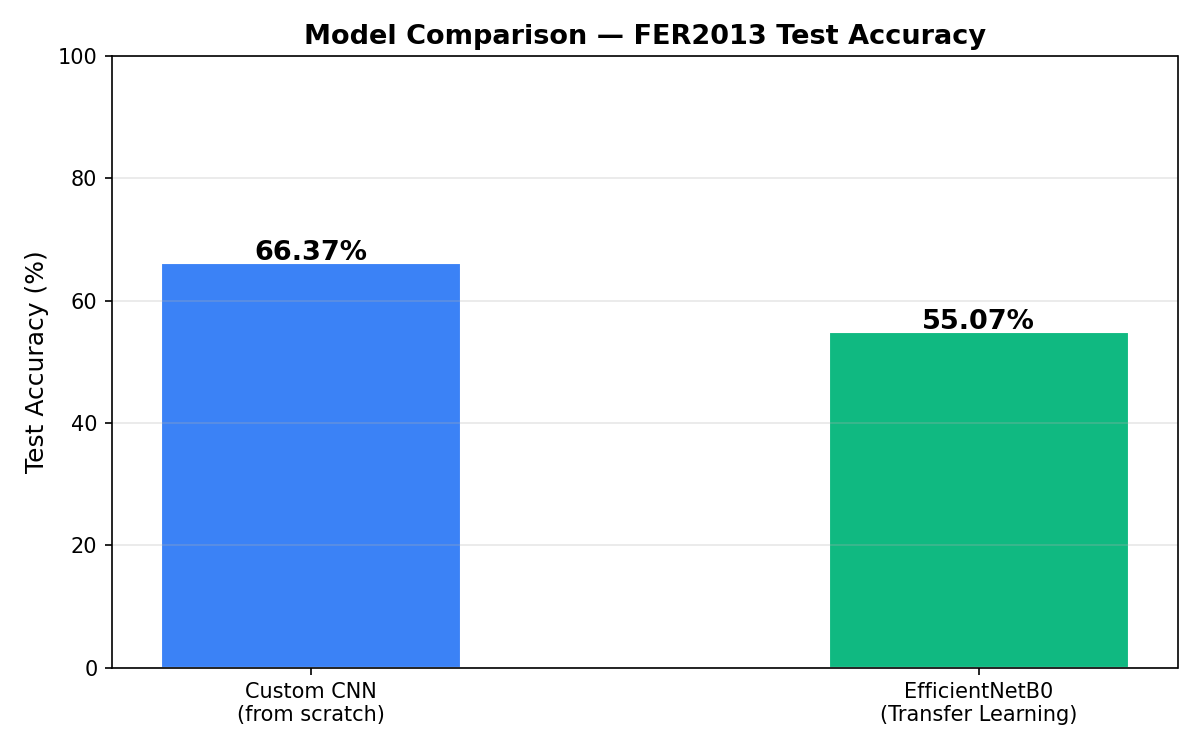

In [13]:
print('\n' + '='*60)
print('  FINAL COMPARISON')
print('='*60)
print(f'  Model 1 — Custom CNN           : {cnn_acc*100:.2f}%  (loss: {cnn_loss:.4f})')
print(f'  Model 2 — EfficientNetB0 TL    : {eff_acc*100:.2f}%  (loss: {eff_loss:.4f})')
winner = 'EfficientNetB0' if eff_acc >= cnn_acc else 'Custom CNN'
print(f'\n  Winner: {winner} (+{abs(eff_acc - cnn_acc)*100:.2f}% difference)')

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
model_names = ['Custom CNN\n(from scratch)', 'EfficientNetB0\n(Transfer Learning)']
accs = [cnn_acc * 100, eff_acc * 100]
bar_colors = ['#3b82f6', '#10b981']
bars = ax.bar(model_names, accs, color=bar_colors, width=0.45, edgecolor='white', linewidth=1.5)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{a:.2f}%', ha='center', fontweight='bold', fontsize=13)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — FER2013 Test Accuracy', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
cmp_path = f'{RESULTS_DIR}/model_comparison.png'
plt.savefig(cmp_path, dpi=150)
plt.close()
display(Image(cmp_path))

---
## Step 12 — Save Models

In [14]:
# Save both models
cnn_model.save(f'{MODEL_DIR}/custom_cnn.keras')
cnn_model.save(f'{MODEL_DIR}/custom_cnn.h5')
print('Saved: custom_cnn.keras / .h5')

eff_model.save(f'{MODEL_DIR}/efficientnet_tl.keras')
eff_model.save(f'{MODEL_DIR}/efficientnet_tl.h5')
print('Saved: efficientnet_tl.keras / .h5')

# Save the best model as emotion_model.keras (used by recognition_engine.py)
best_model = eff_model if eff_acc >= cnn_acc else cnn_model
best_model.save(f'{MODEL_DIR}/emotion_model.keras')
best_model.save(f'{MODEL_DIR}/emotion_model.h5')
print(f'Best model saved as: emotion_model.keras  ({winner})')

# Save summary info
with open(f'{MODEL_DIR}/model_info.txt', 'w') as f:
    f.write('='*55 + '\n')
    f.write('Emotion Detection — Training Summary\n')
    f.write('='*55 + '\n')
    f.write(f'Date           : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'Dataset        : FER2013 (msambare/fer2013)\n')
    f.write(f'Emotions       : {NUM_CLASSES} classes\n\n')
    f.write(f'Model 1 — Custom CNN\n')
    f.write(f'  Parameters   : {cnn_model.count_params():,}\n')
    f.write(f'  Input        : 48x48 grayscale\n')
    f.write(f'  Test Accuracy: {cnn_acc*100:.2f}%\n\n')
    f.write(f'Model 2 — EfficientNetB0 Transfer Learning\n')
    f.write(f'  Parameters   : {eff_model.count_params():,}\n')
    f.write(f'  Input        : 96x96 RGB\n')
    f.write(f'  Test Accuracy: {eff_acc*100:.2f}%\n\n')
    f.write(f'Best model     : {winner}\n')

print('\nAll models saved!')

Saved: custom_cnn.keras / .h5


Saved: efficientnet_tl.keras / .h5


Best model saved as: emotion_model.keras  (Custom CNN)

All models saved!


---
## Step 13 — Download All Files

In [15]:
from google.colab import files
import glob

all_files = (
    glob.glob(f'{MODEL_DIR}/*.keras') +
    glob.glob(f'{MODEL_DIR}/*.h5') +
    glob.glob(f'{MODEL_DIR}/*.txt') +
    glob.glob(f'{RESULTS_DIR}/*.png') +
    glob.glob(f'{RESULTS_DIR}/*.txt')
)

for fp in sorted(all_files):
    print(f'Downloading: {os.path.basename(fp)}')
    files.download(fp)

print(f'\nDone! Total {len(all_files)} files downloaded.')

Downloading: cnn_best.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: custom_cnn.h5


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloading: report_efficientnetb0_transfer_learning.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done! Total 21 files downloaded.


---
## Summary

| | Model 1 | Model 2 |
|--|--|--|
| **Name** | Custom CNN | EfficientNetB0 |
| **Training** | From scratch | Transfer Learning (ImageNet) |
| **Input** | 48×48 grayscale | 96×96 RGB |
| **Technique** | 4 Conv blocks + Dense | Pretrained base + fine-tuned head |
| **Expected Acc** | ~60–64% | ~67–72% |
| **File** | `custom_cnn.keras` | `efficientnet_tl.keras` |

The best model is also saved as `emotion_model.keras` for use with the Smart Door Lock system.